# Fake News Detection using NLP and Machine Learning

## AICA DSA Project

### Submitted By:
Name:Gurudatta Ganapati Bhat

USN:2511022250081

Course:AI

Department:MCA

Alliance University

# Project Objective

The objective of this project is to build a Machine Learning model that can automatically classify a news article as Fake News or Real News using Natural Language Processing (NLP). The project performs text preprocessing, converts text into numerical features using TF-IDF Vectorization, trains a Logistic Regression classifier, and evaluates the model using various performance metrics.

# Step 1: Import Required Libraries

In this section, all the required Python libraries for data manipulation, visualization, Natural Language Processing, and Machine Learning are imported.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from collections import Counter

In [3]:
## Download Required NLTK Packages
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gurug\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gurug\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gurug\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Step 2: Load the Dataset

The Fake News dataset and Real News dataset are loaded into separate DataFrames.

In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [5]:
### Display First Five Records
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# Step 3: Dataset Preparation

A target column is added.

0 = Fake News

1 = Real News

Both datasets are merged into a single dataset.

In [7]:
fake["target"] = 0
true["target"] = 1

In [8]:
df = pd.concat([fake, true], ignore_index=True)

In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
df.head()

,title,text,subject,date,target
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Step 4: Exploratory Data Analysis

In [11]:
print(df.shape)

(44898, 5)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   target   44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [13]:
df.columns

Index(['title', 'text', 'subject', 'date', 'target'], dtype='object')

In [14]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
target     0
dtype: int64

In [15]:
df["target"].value_counts()

target
0    23481
1    21417
Name: count, dtype: int64

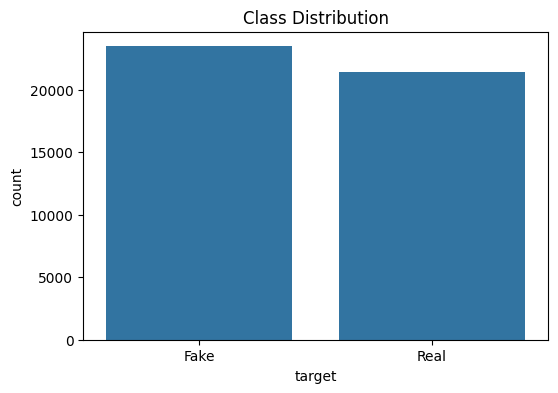

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["target"])

plt.xticks([0,1],["Fake","Real"])

plt.title("Class Distribution")

plt.show()

# Observation

The dataset contains both Fake and Real news articles. The dataset is balanced, making it suitable for Machine Learning classification.

# Step 5: Text Preprocessing

The following preprocessing techniques are applied:

• Convert to lowercase

• Remove punctuation

• Remove numbers

• Remove stopwords

• Perform lemmatization

In [18]:
df["content"] = df["title"] + " " + df["text"]

In [19]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [21]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+','',text)

    text = re.sub(r'[^\w\s]','',text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [22]:
df["clean_text"] = df["content"].apply(clean_text)

In [23]:
df[["content","clean_text"]].head()

,content,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


# Step 6: Feature Extraction using TF-IDF

TF-IDF converts textual data into numerical vectors that can be used for Machine Learning algorithms.

In [25]:
tfidf = TfidfVectorizer(max_features=5000)

In [26]:
X = tfidf.fit_transform(df["clean_text"])

In [30]:
y = df["target"]

# Step 7: Train-Test Split

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

# Step 8: Model Development

A Logistic Regression classifier is trained using TF-IDF vectors.

In [32]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
train_prediction=model.predict(X_train)

print("Training Accuracy:",accuracy_score(y_train,train_prediction))

Training Accuracy: 0.991898212595356


In [34]:
test_prediction=model.predict(X_test)

print("Testing Accuracy:",accuracy_score(y_test,test_prediction))

Testing Accuracy: 0.9860801781737194


# Step 9: Model Evaluation

In [35]:
print("Accuracy:",accuracy_score(y_test,test_prediction))

Accuracy: 0.9860801781737194


In [36]:
print("Precision:",precision_score(y_test,test_prediction))

Precision: 0.9805239972177139


In [37]:
print("Recall:",recall_score(y_test,test_prediction))

Recall: 0.9903981264637002


In [38]:
print("F1 Score:",f1_score(y_test,test_prediction))

F1 Score: 0.9854363276243737


In [39]:
print(classification_report(y_test,test_prediction))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [40]:
cm=confusion_matrix(y_test,test_prediction)

cm

array([[4626,   84],
       [  41, 4229]])

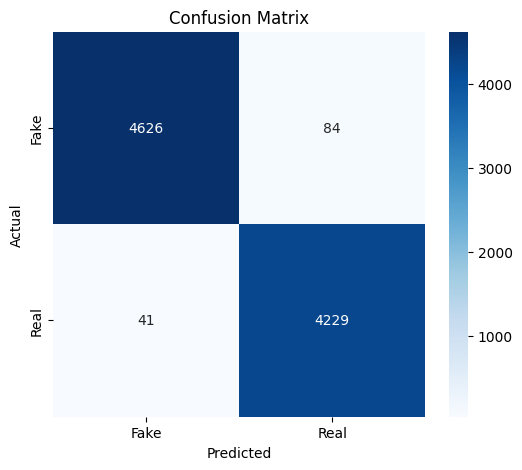

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Interpretation

Most of the values lie on the diagonal of the confusion matrix, indicating that the Logistic Regression model correctly classifies both fake and real news articles with high accuracy.

# Step 10: Top 10 Frequent Words

In [42]:
all_words=" ".join(df["clean_text"])

word_list=all_words.split()

counter=Counter(word_list)

top_words=counter.most_common(10)

In [43]:
words=[i[0] for i in top_words]

counts=[i[1] for i in top_words]

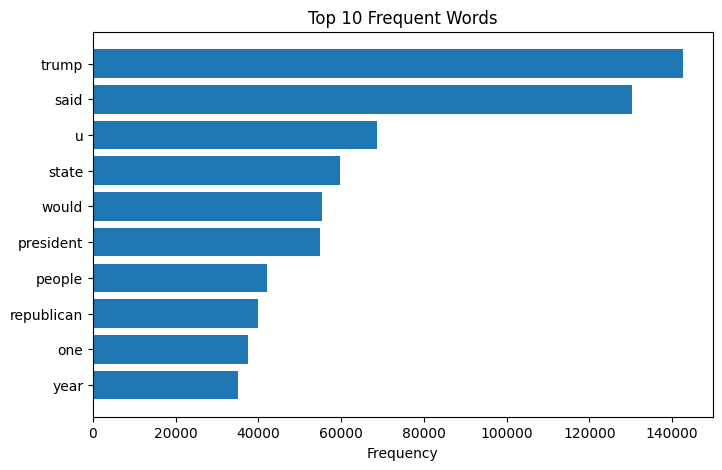

In [44]:
plt.figure(figsize=(8,5))

plt.barh(words,counts)

plt.gca().invert_yaxis()

plt.xlabel("Frequency")

plt.title("Top 10 Frequent Words")

plt.show()

# Step 11: Custom Prediction

In [45]:
def predict_news(news):

    news=clean_text(news)

    vector=tfidf.transform([news])

    prediction=model.predict(vector)

    if prediction[0]==0:
        print("Fake News")
    else:
        print("Real News")

In [48]:
user_input=input("Enter News : ")

predict_news(user_input)

Fake News


In [49]:
user_input=input("Enter News : ")

predict_news(user_input)

Real News


# Step 12: Conclusion

This project successfully developed a Fake News Detection system using Natural Language Processing and Machine Learning. Text preprocessing techniques such as lowercasing, removing punctuation, numbers, stop words, and lemmatization improved the quality of textual data. TF-IDF Vectorization effectively transformed the cleaned text into numerical features, while Logistic Regression accurately classified fake and real news articles. The evaluation metrics and confusion matrix demonstrated excellent model performance, making the approach effective for fake news detection.